# ☁️ Cloud-Based Expense Tracker & Analyzer

A cloud-based application for analyzing personal expense data using Google Colab, Python, Pandas, and Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Date": [
        "2026-01-02", "2026-01-05", "2026-01-08",
        "2026-01-15", "2026-01-20",
        "2026-02-03", "2026-02-10", "2026-02-18",
        "2026-02-25",
        "2026-03-04", "2026-03-12", "2026-03-20",
        "2026-03-28",
        "2026-04-05", "2026-04-15", "2026-04-25",
        "2026-05-02", "2026-05-14", "2026-05-26",
        "2026-06-03", "2026-06-17", "2026-06-28"
    ],

    "Category": [
        "Food", "Travel", "Shopping",
        "Bills", "Entertainment",
        "Food", "Travel", "Shopping",
        "Bills",
        "Food", "Entertainment", "Travel",
        "Shopping",
        "Bills", "Food", "Entertainment",
        "Travel", "Shopping", "Food",
        "Bills", "Entertainment", "Travel"
    ],

    "Description": [
        "Lunch", "Bus", "Clothes",
        "Electricity", "Movie",
        "Dinner", "Auto", "Shoes",
        "Internet",
        "Breakfast", "Netflix", "Cab",
        "Accessories",
        "Electricity", "Lunch", "Movie",
        "Train", "Clothes", "Dinner",
        "Internet", "Concert", "Bus"
    ],

    "Amount": [
        250, 80, 1800,
        1200, 500,
        450, 120, 2200,
        1000,
        180, 650, 300,
        900,
        1300, 350, 500,
        700, 1600, 400,
        950, 1200, 100
    ],

    "Payment_Mode": [
        "UPI", "Cash", "Card",
        "UPI", "Card",
        "UPI", "Cash", "Card",
        "UPI",
        "Cash", "Card", "UPI",
        "Card",
        "UPI", "Cash", "Card",
        "UPI", "Card", "UPI",
        "UPI", "Card", "Cash"
    ]
}

df = pd.DataFrame(data)

df.head()

,Date,Category,Description,Amount,Payment_Mode
0,2026-01-02,Food,Lunch,250,UPI
1,2026-01-05,Travel,Bus,80,Cash
2,2026-01-08,Shopping,Clothes,1800,Card
3,2026-01-15,Bills,Electricity,1200,UPI
4,2026-01-20,Entertainment,Movie,500,Card


In [6]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.strftime("%B")

df.head()
print("Number of Transactions:", len(df))
print("Total Expenditure: ₹", f"{df['Amount'].sum():,.2f}")
print("Average Expense: ₹", f"{df['Amount'].mean():,.2f}")
total_expense = df["Amount"].sum()

print("💰 Total Expenditure: ₹", f"{total_expense:,.2f}")
highest_expense = df.loc[df["Amount"].idxmax()]

print("🏆 Highest Expense")
print("----------------------")
print("Description:", highest_expense["Description"])
print("Category:", highest_expense["Category"])
print("Amount: ₹", highest_expense["Amount"])
print("Date:", highest_expense["Date"].date())
category_expense = (
    df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("📊 Spending by Category")
print("------------------------")
print(category_expense)
highest_category = category_expense.idxmax()

print("🏆 Highest Spending Category:", highest_category)
print("Amount Spent: ₹", f"{category_expense.max():,.2f}")

Number of Transactions: 22
Total Expenditure: ₹ 16,730.00
Average Expense: ₹ 760.45
💰 Total Expenditure: ₹ 16,730.00
🏆 Highest Expense
----------------------
Description: Shoes
Category: Shopping
Amount: ₹ 2200
Date: 2026-02-18
📊 Spending by Category
------------------------
Category
Shopping         6500
Bills            4450
Entertainment    2850
Food             1630
Travel           1300
Name: Amount, dtype: int64
🏆 Highest Spending Category: Shopping
Amount Spent: ₹ 6,500.00


💳 Spending by Payment Mode
----------------------------
Payment_Mode
Card    9350
UPI     6550
Cash     830
Name: Amount, dtype: int64
📅 Monthly Expenditure
----------------------
Month
April       2150
February    3770
January     3830
June        2250
March       2030
May         2700
Name: Amount, dtype: int64


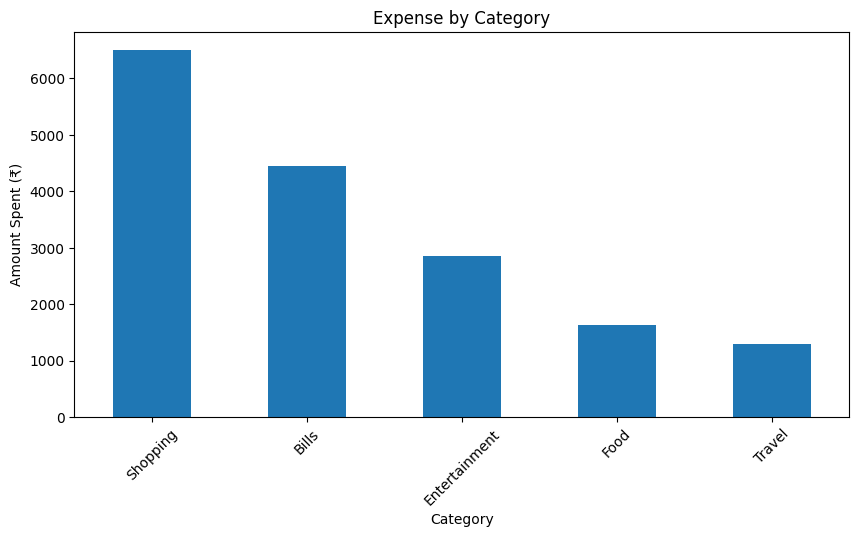

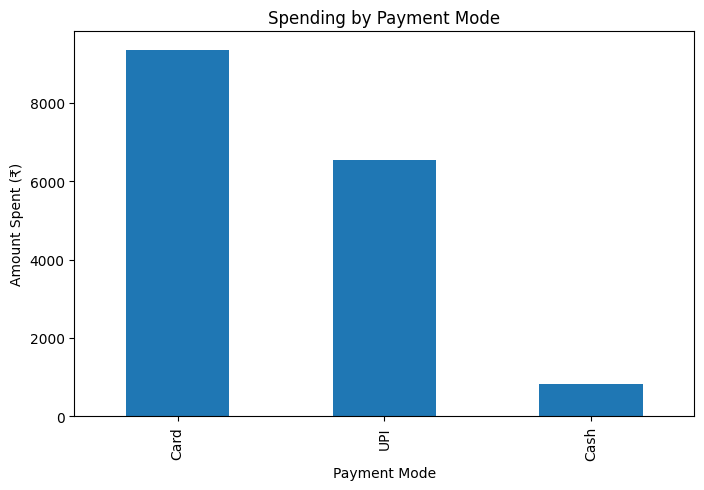

In [7]:
payment_expense = (
    df.groupby("Payment_Mode")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("💳 Spending by Payment Mode")
print("----------------------------")
print(payment_expense)

monthly_expense = df.groupby("Month")["Amount"].sum()

print("📅 Monthly Expenditure")
print("----------------------")
print(monthly_expense)
plt.figure(figsize=(10, 5))

category_expense.plot(kind="bar")

plt.title("Expense by Category")
plt.xlabel("Category")
plt.ylabel("Amount Spent (₹)")
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8, 5))

payment_expense.plot(kind="bar")

plt.title("Spending by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Amount Spent (₹)")

plt.show()

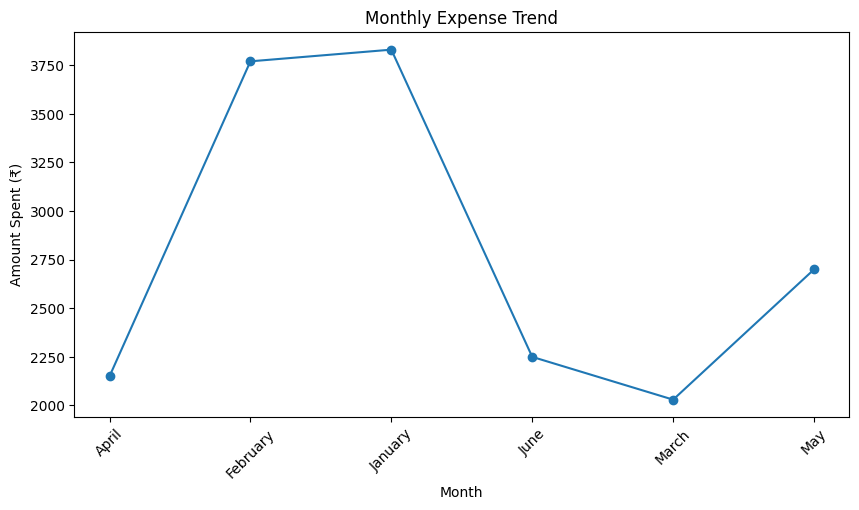

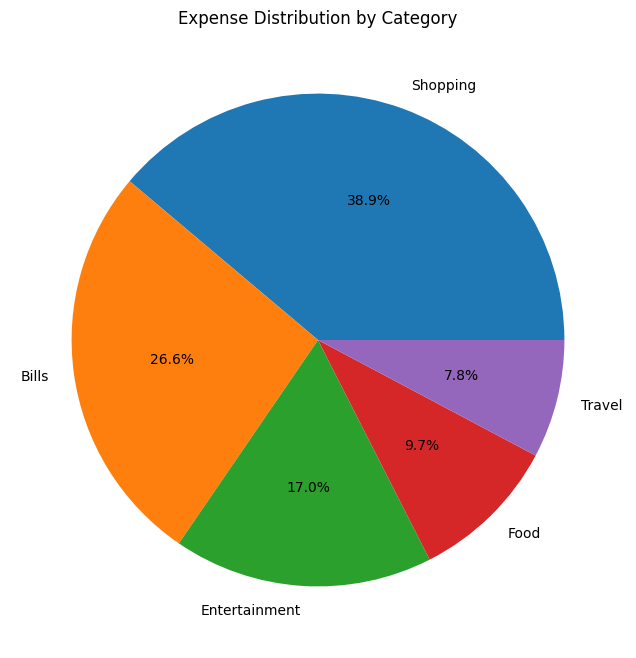

In [8]:
plt.figure(figsize=(10, 5))

monthly_expense.plot(kind="line", marker="o")

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Amount Spent (₹)")
plt.xticks(rotation=45)

plt.show()
plt.figure(figsize=(8, 8))

category_expense.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Expense Distribution by Category")
plt.ylabel("")

plt.show()

In [9]:
total_expense = df["Amount"].sum()
total_transactions = len(df)
average_expense = df["Amount"].mean()
highest_expense_value = df["Amount"].max()

print("=" * 50)
print("          ☁️ EXPENSE DASHBOARD")
print("=" * 50)

print(f"💰 Total Expenditure   : ₹{total_expense:,.2f}")
print(f"🧾 Transactions        : {total_transactions}")
print(f"📊 Average Expense     : ₹{average_expense:,.2f}")
print(f"🏆 Highest Expense     : ₹{highest_expense_value:,.2f}")
print(f"📌 Top Category        : {highest_category}")

print("=" * 50)
print("💡 SPENDING INSIGHTS")
print("=" * 50)

print(
    f"1. Your highest spending category is "
    f"{highest_category}, with ₹{category_expense.max():,.2f} spent."
)

print(
    f"2. Your largest individual expense was "
    f"₹{highest_expense_value:,.2f} on "
    f"{highest_expense['Description']}."
)

highest_payment_mode = payment_expense.idxmax()

print(
    f"3. Your most-used spending method by amount is "
    f"{highest_payment_mode}."
)

highest_month = monthly_expense.idxmax()

print(
    f"4. Your highest spending month was "
    f"{highest_month}, with ₹{monthly_expense.max():,.2f}."
)

          ☁️ EXPENSE DASHBOARD
💰 Total Expenditure   : ₹16,730.00
🧾 Transactions        : 22
📊 Average Expense     : ₹760.45
🏆 Highest Expense     : ₹2,200.00
📌 Top Category        : Shopping
💡 SPENDING INSIGHTS
1. Your highest spending category is Shopping, with ₹6,500.00 spent.
2. Your largest individual expense was ₹2,200.00 on Shoes.
3. Your most-used spending method by amount is Card.
4. Your highest spending month was January, with ₹3,830.00.


## 📤 Upload Your Own Expense Dataset

In [ ]:
uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename)

print("Dataset uploaded successfully!")

df.head()

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.strftime("%B")

print("Dataset prepared successfully!")
df.head()